### Import and reading data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# import os
# import ctypes

# # Force the dynamic linker to find libR.so before rpy2 tries to load
# try:
#     ctypes.CDLL('/usr/lib/R/lib/libR.so', mode=ctypes.RTLD_GLOBAL)
# except Exception as e:
#     print(f"Manual link failed: {e}")

# os.environ['R_HOME'] = '/usr/lib/R'
# os.environ['LD_LIBRARY_PATH'] = '/usr/lib/R/lib'

In [3]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
import pickle
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities
import numpy as np
import pandas as pd



In [4]:
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
# os.chdir('/Users/Apc/graphical-sampling/simulations')
os.chdir('/home/dell/projects/graphical-sampling/simulations')

In [5]:
# ============================================================
# DESIGN SEARCH FUNCTION
# ============================================================

def search_best_design(

    pop,
    n,

    # ========================================================
    # CRITERION
    # ========================================================

    criterion='MI',

    # ========================================================
    # MULTI-OBJECTIVE WEIGHTS
    # ========================================================

    w1=0.5,
    w2=0.5,

    moran_scale=0.05,
    var_scale=1000,

    # ========================================================
    # SEARCH SPACE
    # ========================================================

    point_strategies=[

        'None',

        'lexico_xy',
        'lexico_yx',

        'projection',
        'dist_from_origin',

        'angle',
        'spiral',

        'hilbert',

        'snake',

        'knight_move',

        'random',
    ],

    zone_strategies=[

        'None',

        'lexico_xy',
        'lexico_yx',

        'projection',
        'dist_from_origin',

        'angle',
        'spiral',

        'hilbert',

        'snake',

        'knight_move',

        'random',
    ],

    zone_modes=[
        'sweep_xy',
        'sweep_yx'
    ],

    num_splits=[1],

    shift_jumps=[1],

    num_zones_cluster=[100],

    num_zones_sweep=[(5, 5)],

    # ========================================================
    # CLUSTERING
    # ========================================================

    centroid_grid_x=10,

    r_sample_per_cluster=1,

    # ========================================================
    # ORDER OPTIONS
    # ========================================================

    topological=False,

    shuffle=False,
):

    # ========================================================
    # CRITERION NAMES
    # ========================================================

    criterion_name_map = {

        'MI': 'Moran',

        'VAR': 'Variance',

        'MI_VAR': 'Moran + Variance',

        'VI': 'Voronoi',

        'DI': 'Density',

        'BI': 'Balance',
    }

    criterion_name = criterion_name_map[criterion]

    # ========================================================
    # STORAGE
    # ========================================================

    track = []

    best_val = float('inf')

    best_design = None

    # ========================================================
    # TOTAL ITERATIONS
    # ========================================================

    num_designs = (

        len(point_strategies)

        * len(zone_strategies)

        * len(zone_modes)

        * len(num_splits)

        * len(shift_jumps)
    )

    # ========================================================
    # PROGRESS BAR
    # ========================================================

    pbar = tqdm(

        product(

            point_strategies,

            zone_strategies,

            zone_modes,

            num_splits,

            shift_jumps
        ),

        total=num_designs
    )

    # ========================================================
    # SEARCH LOOP
    # ========================================================

    for (

        point_strategy,

        zone_strategy,

        zone_mode,

        num_split,

        shift_jump

    ) in pbar:

        # ----------------------------------------------------
        # ZONE CONFIGURATIONS
        # ----------------------------------------------------

        list_of_num_zones = (

            num_zones_cluster

            if zone_mode == 'cluster'

            else num_zones_sweep
        )

        for num_zones in list_of_num_zones:

            # =================================================
            # CLUSTERING
            # =================================================

            fbn = gs.clustering.FIPBalancedNMeans(

                n=n,

                centroid_grid_x=centroid_grid_x,

                r_sample_per_cluster=r_sample_per_cluster,

                init_clust_method='expanded',

                split_size=1
            )

            fbn.fit(pop)

            fbn.fit_zones(

                num_zones=num_zones,

                mode=zone_mode
            )

            try:

                # =============================================
                # BUILD ORDER
                # =============================================

                order = gs.Order.from_clusters(

                    pop,

                    fbn.clusters,

                    zone_strategy=zone_strategy,

                    point_strategy=point_strategy,

                    num_splits=num_split,

                    topological=topological,

                    shift_jump=shift_jump,

                    shuffle=shuffle,

                    grid_dims=(
                        num_zones
                        if isinstance(num_zones, tuple)
                        else None
                    ),
                )

                # =============================================
                # CREATE DESIGN
                # =============================================

                design = gs.Design.from_order(pop, order)

                # =============================================
                # CRITERIA
                # =============================================

                moran_val = design.moran[0]

                design._nht_variance = None

                var_val = design.nht_variance

                # =============================================
                # OBJECTIVE FUNCTION
                # =============================================

                match criterion:

                    case 'MI':

                        val = moran_val

                    case 'VAR':

                        val = var_val

                    case 'MI_VAR':

                        standardized_moran = (
                            moran_val
                            / (moran_scale + 1e-12)
                        )

                        standardized_variance = (
                            var_val
                            / (var_scale + 1e-12)
                        )

                        val = (

                            w1 * standardized_moran

                            +

                            w2 * standardized_variance
                        )

                    case 'VI':

                        val = design.voronoi

                    case 'DI':

                        val = design.density_disparity

                    case 'BI':

                        val = design.local_balance

                    case _:

                        raise ValueError(
                            f"Unknown criterion: {criterion}"
                        )

                # =============================================
                # LABELS
                # =============================================

                combo = (
                    f"{zone_strategy}"
                    f" → "
                    f"{point_strategy}"
                )

                # =============================================
                # INITIAL BASELINE
                # =============================================

                if len(track) == 0:

                    best_val = val

                    print(

                        f"[INITIAL] "

                        f"{criterion_name}: {val:.6f} | "

                        f"{combo}"
                    )

                # =============================================
                # IMPROVEMENT
                # =============================================

                if val < best_val:

                    best_val = val

                    best_design = design

                    print(

                        f"[NEW BEST] "

                        f"Objective: {val:.6f} | "

                        f"MI: {moran_val:.6f} | "

                        f"VAR: {var_val:.2f} | "

                        f"{combo:<30} | "

                        f"Mode: {zone_mode:<8} | "

                        f"Zones: {num_zones} | "

                        f"Jump: {shift_jump}"
                    )
                # =============================================
                # PROGRESS BAR
                # =============================================

                pbar.set_postfix({

                    "Best": f"{best_val:.6f}",

                    "Combo": combo
                })

                # =============================================
                # STORE RESULTS
                # =============================================

                track.append({

                    'value': val,

                    'design': design,

                    'moran': moran_val,

                    'variance': var_val,

                    'zone_strategy': zone_strategy,

                    'point_strategy': point_strategy,

                    'combo': combo,

                    'zone_mode': zone_mode,

                    'num_zones': num_zones,

                    'shift_jump': shift_jump,
                })

            except Exception:

                continue

    # ========================================================
    # NO VALID DESIGNS
    # ========================================================

    if len(track) == 0:

        print("\n[ERROR] No valid designs generated.")

        return None

    # ========================================================
    # SORT RESULTS
    # ========================================================

    results = sorted(

        track,

        key=lambda x: x['value']
    )

    best = results[0]

    # ========================================================
    # FINAL OUTPUT
    # ========================================================

    print(f"\n{'='*60}")

    print(f"              OPTIMIZATION COMPLETE")

    print(f"{'='*60}")

    print(f"Criterion:       {criterion_name}")

    print(f"Best Objective:  {best['value']:.6f}")

    print(f"Moran:           {best['moran']:.6f}")

    print(f"Variance:        {best['variance']:.6f}")

    print(f"Combination:     {best['combo']}")

    print(f"Zone Mode:       {best['zone_mode']}")

    print(f"Num Zones:       {best['num_zones']}")

    print(f"Shift Jump:      {best['shift_jump']}")

    print(f"{'='*60}")

    # ========================================================
    # RETURN
    # ========================================================

    return {

        'best_design': best['design'],

        'best_value': best['value'],

        'criterion': criterion,

        'moran': best['moran'],

        'variance': best['variance'],

        'best_combo': best['combo'],

        'zone_strategy': best['zone_strategy'],

        'point_strategy': best['point_strategy'],

        'zone_mode': best['zone_mode'],

        'num_zones': best['num_zones'],

        'shift_jump': best['shift_jump'],

        'results': results,

        'track': track,
    }

In [6]:
def robertson_variables(x1, x2, positive_shift=True):

    corrugated = (
        3 * (x1 + x2)
        +
        np.sin(6 * (x1 + x2))
    )

    peak = (
        (
            3 * (4 - 6*x1)**2
            *
            np.exp(
                -(6*x1 - 3)**2
                -
                (6*x2 - 2)**2
            )
            -
            10
            *
            (
                0.2*(6*x1 - 3)
                -
                (6*x1 - 3)**3
                -
                (6*x2 - 3)**5
            )
            *
            np.exp(
                -(6*x1 - 3)**2
                -
                (6*x2 - 3)**2
            )
            -
            (1/3)
            *
            np.exp(
                -(6*x1 - 2)**2
                -
                (6*x2 - 3)**2
            )
        )
    )

    bird = (
        1/20
        *
        (
            (12*x1 - 12*x2)**2
            +
            np.exp(
                (1 - np.sin(12*x1 - 6))**2
            )
            *
            np.cos(12*x2 - 6)
            +
            np.exp(
                (1 - np.cos(12*x2 - 6))**2
            )
            *
            np.sin(12*x1 - 6)
        )
    )

    if positive_shift:

        peak = peak + 7

        bird = bird + 6

    return {

        "corrugated": corrugated,

        "plane": corrugated,

        "peak": peak,

        "bird": bird,
    }

In [ ]:
# =========================================================
# LOAD POPULATIONS
# =========================================================

import os
import pandas as pd
import numpy as np

from package_sampling.utils import inclusion_probabilities

# =========================================================
# FILES
# =========================================================

files = [

    "meuse.csv",

    "swiss.csv",

    "AggregatedPop1000.csv",

    "RegularPop1000.csv"
]

# =========================================================
# POPULATION LOADER
# =========================================================

def popus(n, path="populations/real"):

    dfs = {}

    for f in files:

        full_path = os.path.join(path, f)

        # -------------------------------------------------
        # Check existence
        # -------------------------------------------------

        if not os.path.exists(full_path):

            print(f"Warning: {full_path} not found.")

            continue

        # -------------------------------------------------
        # Read file
        # -------------------------------------------------

        df = pd.read_csv(full_path)

        N_pop = len(df)

        name = f.replace(".csv", "")

        # -------------------------------------------------
        # Equal probabilities
        # -------------------------------------------------

        pik_ep = np.repeat(
            n / N_pop,
            N_pop
        )


        # =================================================
        # ROBERTSON POPULATIONS
        # =================================================

        if f in ["AggregatedPop1000.csv", "RegularPop1000.csv"]:

            coords = df.to_numpy()

            x1 = coords[:, 0]
            x2 = coords[:, 1]

            vars_robertson = robertson_variables(x1, x2)

            plane = vars_robertson["plane"]

            def correlated_with(x, rho, seed=None):

                rng = np.random.default_rng(seed)

                x_std = (x - x.mean()) / x.std()

                e = rng.normal(size=len(x_std))
                e = (e - e.mean()) / e.std()

                y_std = rho * x_std + np.sqrt(1 - rho**2) * e

                return y_std

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : x1,
                "coord_y" : x2,

                "pik_ep" : pik_ep,

                "z" : vars_robertson["corrugated"],

                "plane" : plane,
                "peak" : vars_robertson["peak"],
                "bird" : vars_robertson["bird"],

                "plane_rho_07" : correlated_with(plane, 0.7, seed=701),
                "plane_rho_08" : correlated_with(plane, 0.8, seed=801),
                "plane_rho_09" : correlated_with(plane, 0.9, seed=901),
            })

        # =================================================
        # MEUSE
        # =================================================

        elif f == "meuse.csv":

            coords = df[["x", "y"]].to_numpy()

            # unequal probabilities
            pik_up = inclusion_probabilities(

                df["copper"].to_numpy().copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["cadmium"]
            })

        # =================================================
        # SWISS
        # =================================================

        elif f == "swiss.csv":

            coords = df[["x", "y"]].to_numpy()

            AREA = df["AREA"].to_numpy().clip(
                5,
                100
            )

            pik_up = inclusion_probabilities(

                AREA.copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["AREA_A"]
            })

    return dfs

# =========================================================
# LOAD MAIN POPULATIONS
# =========================================================

p50 = popus(50)

regular = p50["df_RegularPop1000"]

aggregated = p50["df_AggregatedPop1000"]

meuse = p50["df_meuse"]

swiss = p50["df_swiss"]

# =========================================================
# CHECK
# =========================================================

print("\n================================================")
print("POPULATIONS LOADED")
print("================================================\n")

print("regular:", regular.shape)

print("aggregated:", aggregated.shape)

print("meuse:", meuse.shape)

print("swiss:", swiss.shape)


POPULATIONS LOADED

regular: (1000, 7)
aggregated: (1000, 7)
meuse: (155, 5)
swiss: (959, 5)


In [8]:
# changing the angle of the population for testing the robustness of the sampling algorithms

import numpy as np
import pandas as pd

def rotate_population(df, alpha_degrees):
    # Convert angle to radians
    alpha_rad = np.radians(alpha_degrees)
    
    # Rotation Matrix components
    cos_a = np.cos(alpha_rad)
    sin_a = np.sin(alpha_rad)
    
    # Extract coordinates
    x = df['coord_x'].values
    y = df['coord_y'].values
    
    # Apply Rotation:
    # x' = x*cos(a) - y*sin(a)
    # y' = x*sin(a) + y*cos(a)
    df['coord_x'] = x * cos_a - y * sin_a
    df['coord_y'] = x * sin_a + y * cos_a
    
    return df

# Example use: Rotate 45 degrees
# df_rotated = rotate_population(df.copy(), 45)

In [9]:
# Diagnostic function to check inclusion probabilities and plot deviations

import numpy as np
import matplotlib.pyplot as plt

def check_inclusions(design, plot=True, title="FIP Deviation"):
    """
    Performs a statistical diagnostic on the design to ensure 
    Inclusion Probabilities (FIP) are perfectly preserved.
    """
    # 1. Extract Data
    empirical_fip = design.fip 
    target_fip = design.pop.inclusions
    diff = empirical_fip - target_fip
    max_dev = np.abs(diff).max()

    # 2. Print Summary
    print(f"--- Inclusion Probability Diagnostic ---")
    print(f"Total Design Mass: {empirical_fip.sum():.6f} (Target: {design.pop.n})")
    print(f"Max Absolute Deviation: {max_dev:.2e}")
    print(f"Mean Absolute Deviation: {np.abs(diff).mean():.2e}")

    # 3. Validation Logic
    if np.allclose(empirical_fip, target_fip, atol=1e-6):
        print("✅ SUCCESS: Inclusion probabilities are perfectly preserved!")
    else:
        fixed_count = len(design.order.fixed_ids)
        print(f"❌ WARNING: Significant deviation! Frozen units: {fixed_count}")

    # 4. Optional Plotting
    if plot:
        plt.figure(figsize=(10, 2))
        plt.plot(diff, color='red', lw=1, alpha=0.7)
        plt.title(f"{title} (Max Dev: {max_dev:.2e})")
        plt.axhline(0, color='black', lw=0.5, ls='--')
        plt.ylabel("Delta")
        plt.xlabel("Unit Index")
        plt.grid(True, alpha=0.2)
        plt.show()

In [10]:
# Function to save the full GBFS engine state, including the search frontier and best design
import os
import pickle
from datetime import datetime

def save_gbfs_state(engine, folder="best_designs"):
    """
    Saves the full GBFS engine state, including the search frontier and best design.
    """
    os.makedirs(folder, exist_ok=True)
    
    # Extract metadata for a clean filename
    pop_label = getattr(engine.best_design.pop, 'label', 'pop').replace(" ", "_")
    score = engine.best_criteria_value
    timestamp = datetime.now().strftime("%m%d_%H%M")
    
    # Detect current zone configuration from the best design
    # This helps identify if the file is a 40Z or 1Z version
    num_clusters = len(engine.best_design.order.clusters)
    num_zones = len(engine.best_design.order.clusters[0].zones) if num_clusters > 0 else 0
    
    filename = f"GRIZZLY_{pop_label}_C{num_clusters}Z{num_zones}_score{score:.4f}_pop_{popu}_{timestamp}.pkl"
    save_path = os.path.join(folder, filename)
    
    with open(save_path, 'wb') as f:
        pickle.dump(engine, f)
    
    print(f"✅ Full search state saved: {save_path}")
    print(f"Candidates waiting in Open Set: {len(engine.open_set)}")
    return save_path

In [11]:
# Function to Save Initila and Best Design, 
import os
import pickle
from datetime import datetime

def save_design(design, folder="best_designs", name_prefix="INITIAL"):
    """
    Save a single Design object.
    """
    os.makedirs(folder, exist_ok=True)

    # Population label
    pop_label = getattr(design.pop, 'label', 'pop').replace(" ", "_")

    # Structure info
    num_clusters = len(design.order.clusters) if design.order.clusters else 1
    num_zones = len(design.order.clusters[0].zones) if design.order.clusters else 1

    # Timestamp
    timestamp = datetime.now().strftime("%m%d_%H%M")

    filename = (
        f"{name_prefix}_{pop_label}"
        f"_C{num_clusters}Z{num_zones}"
        f"_pop_{popu}_{timestamp}.pkl"
    )

    save_path = os.path.join(folder, filename)

    with open(save_path, 'wb') as f:
        pickle.dump(design, f)

    print(f"✅ Design saved: {save_path}")

    return save_path

In [12]:
# Function to load a saved GBFS engine state from the best_designs folder

def load_gbfs_state(filename):
    """
    Loads a saved GBFS engine state from the best_designs folder.
    """
    # Ensure we look in the right folder if only a filename is provided
    if not os.path.exists(filename):
        filename = os.path.join("best_designs", filename)
        
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            loaded_engine = pickle.load(f)
        
        print(f"🚀 Grizzly Resumed!")
        print(f"Best Score Found: {loaded_engine.best_criteria_value:.6f}")
        print(f"Hierarchy State:  {len(loaded_engine.best_design.order.clusters)} Clusters")
        print(f"Frontier Size:    {len(loaded_engine.open_set)} candidates")
        return loaded_engine
    else:
        print(f"❌ File not found: {filename}")
        return None

In [13]:
# Fucntion to load One Design, Best or Initial
import pickle

def load_design(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

In [14]:
def release_full_grizzly(old_engine):
    """
    Takes a restricted engine (40 zones), flattens every single candidate 
    in its open_set, and returns a brand new 'Released' engine.
    """
    print(f"--- Global Release Initiated ---")
    print(f"Processing {len(old_engine.open_set)} candidates from the frontier...")
    
    # 1. First, flatten the absolute best design to use as the "seed"
    flat_best = old_engine.best_design.flatten()
    
    # 2. Create the fresh engine using that flat_best as the initial design
    # This prevents the ValueError: min() arg is empty
    new_engine = gs.search.GreedyBestFirstSearch(initial_designs=[flat_best], criteria=old_engine.criteria)
    
    # 3. Flatten the rest of the Open Set and add them
    flattened_count = 0
    import heapq
    for val, _, move_type, design in old_engine.open_set:
        try:
            # Flatten the candidate
            flat_candidate = design.flatten()
            
            # Avoid duplicating the best_design we already added
            if flat_candidate == flat_best:
                continue
                
            # Push into the new engine's open_set
            heapq.heappush(new_engine.open_set, (val, next(new_engine._counter), 'order_change', flat_candidate))
            flattened_count += 1
        except Exception:
            continue
            
    # 4. Ensure the engine starts with a clean closed_set
    new_engine.closed_set = set()
    
    print(f"✅ Success! New engine populated with {flattened_count + 1} global candidates.")
    print(f"Current Best Score: {new_engine.best_criteria_value:.6f}")
    
    return new_engine

In [15]:
# Debugging function to visualize the swap in the specific zone

from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np
def audit_intelligent_swap(order_obj, coords, idx_i, idx_j, c_idx, z_idx):
    """
    Visualizes the specific zone where a swap is happening.
    """
    plt.figure(figsize=(6, 6))
    
    # 1. Get the specific zone data
    active_zone = order_obj.clusters[c_idx].zones[z_idx]
    zone_indices = active_zone.indices # Use the property to get sorted indices
    
    # 2. Plot all points in the background (faint)
    plt.scatter(coords[:, 0], coords[:, 1], c='gray', s=5, alpha=0.1, label='Population')
    
    # 3. Highlight all points in this SPECIFIC zone
    zone_coords = coords[zone_indices]
    plt.scatter(zone_coords[:, 0], zone_coords[:, 1], c='green', s=20, alpha=0.4, label=f'Zone {z_idx}')
    
    # 4. Draw the Convex Hull of the Zone (The "Green Box")
    if len(zone_coords) >= 3:
        hull = ConvexHull(zone_coords)
        for simplex in hull.simplices:
            plt.plot(zone_coords[simplex, 0], zone_coords[simplex, 1], 'g-', lw=2)
            
    # 5. Highlight the two units being swapped
    # Red = Unit i, Blue = Unit j
    plt.scatter(coords[idx_i, 0], coords[idx_i, 1], c='red', s=100, edgecolors='black', label='Unit I', zorder=5)
    plt.scatter(coords[idx_j, 0], coords[idx_j, 1], c='blue', s=100, edgecolors='black', label='Unit J', zorder=5)
    
    plt.title(f"Cluster {c_idx} | Zone {z_idx} | Swapping ID {idx_i} with {idx_j}")
    plt.legend()
    plt.show()

In [16]:
# srs_var = N**2 * (1-n/N) * np.var(variable)/n

# plain_flat = [
#     N,
#     n,
#     5000,
#     0,
#     np.sum(variable),
#     initial_design.nht_variance,
#     # srs_var / initial_design.nht_variance,
#     0,
#     0,
#     initial_design.density_disparity[0],
#     initial_design.density_disparity[1],
#     initial_design.voronoi[0],
#     initial_design.voronoi[1],
#     initial_design.moran[0],
#     initial_design.moran[1],
#     initial_design.local_balance[0],
#     initial_design.local_balance[1],
# ]

# print(", ".join(map(str, plain_flat)))


### Parameters

<Axes: title={'center': 'FIP Balanced 50-Means Soft Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

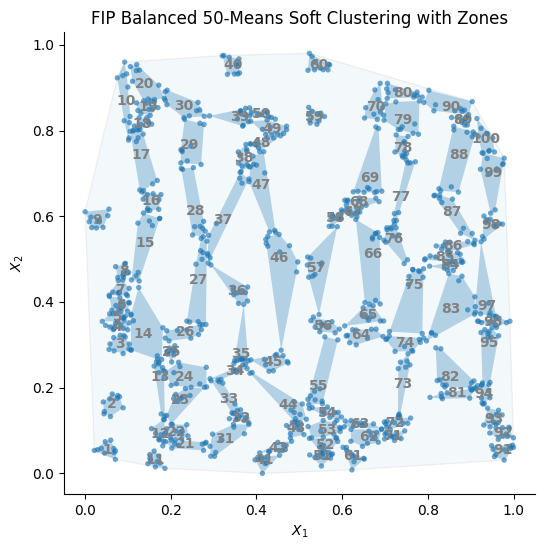

In [28]:
# --- Parameters ---
popu = 'df_AggregatedPop1000'
ep_or_up = 'pik_ep'
n = 50
df = popus(n)[popu]
df = rotate_population(df.copy(),0)
N = len(df)

r_sample_per_cluster = 50
centroid_grid_x =4
centroid_grid_x_zone = 9
num_zones_cluster = [100]
num_zones_sweep = [(10, 10)]
num_splits = [1]
topological = True
shift_jumps = [0]
shuffle=False

# --- Data Preparation ---
target_df = df
coords_data = target_df[['coord_x', 'coord_y']].to_numpy()
inclusions_data = target_df[ep_or_up].to_numpy()
# np.random.seed(123)
# inclusions_data = np.sort(inclusion_probabilities(
#     np.clip(np.random.random(N), .3, .8),
#     n
# ))
variable_data = target_df['z'].to_numpy() if 'z' in target_df.columns else inclusions_data

# --- Population & Clustering ---
pop = gs.Population(coords_data, inclusions_data, n=n, variable=variable_data)

fbn = gs.clustering.FIPBalancedNMeans(
    n=n, 
    centroid_grid_x=centroid_grid_x, 
    r_sample_per_cluster=r_sample_per_cluster, 
    init_clust_method='expanded', 
    split_size=1
)

fbn.fit(pop)
fbn.fit_zones(num_zones=num_zones_sweep[0], mode='sweep_xy')
# fbn.fit_zones(num_zones=num_zones_cluster[0], mode='cluster')

# --- Visualization ---
fbn.plot(mode='soft')

In [29]:
print(f'plane_sum = {target_df['plane'].sum():.1f}, peak_sum = {target_df['peak'].sum():.1f}, bird_sum = {target_df['bird'].sum():.1f}')

plane_sum = 2890.7, peak_sum = 7263.7, bird_sum = 6671.0


### Pre-Process

In [17]:
out = search_best_design(

    pop=pop,

    n=n,
    r_sample_per_cluster = n,
    centroid_grid_x =1,
    num_zones_cluster = [100],
    num_zones_sweep = [(10, 5)],
    num_splits = [1],
    topological = True,
    shift_jumps = [0],
    shuffle=False,

    criterion='MI_VAR',

    w1=0.7,
    w2=0.3,

    moran_scale=0.05,

    var_scale=1000,

    point_strategies=['random'],
    zone_strategies=['random']
)

best_design = out['best_design']

 50%|█████     | 1/2 [00:00<00:00,  2.06it/s, Best=-1.530367, Combo=random → random]

[INITIAL] Moran + Variance: -1.530367 | random → random


100%|██████████| 2/2 [00:00<00:00,  2.02it/s, Best=-2.063070, Combo=random → random]

[NEW BEST] Objective: -2.063070 | MI: -0.175955 | VAR: 1334.32 | random → random                | Mode: sweep_yx | Zones: (10, 5) | Jump: 0

              OPTIMIZATION COMPLETE
Criterion:       Moran + Variance
Best Objective:  -2.063070
Moran:           -0.175955
Variance:        1334.322110
Combination:     random → random
Zone Mode:       sweep_yx
Num Zones:       (10, 5)
Shift Jump:      0


In [18]:
best_initial_design = out['best_design']

best_value = out['best_value']

print(best_value)

len(best_initial_design.all_samples_and_probs[0])

best_initial_design.all_samples_and_probs[1].sum()

-2.0630703343360826


np.float32(1.0)

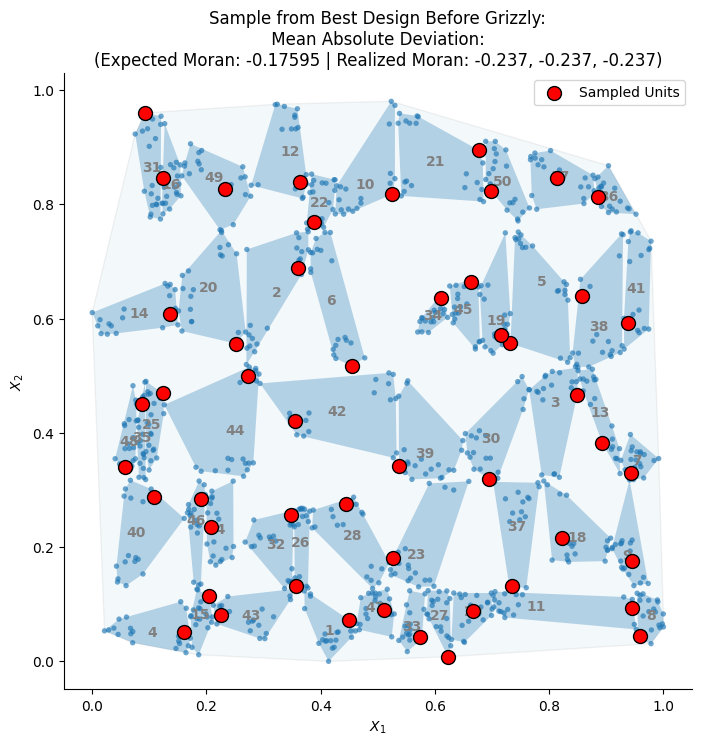

Sampled Unit Indices: [259 260 646 906 788 535 803 165 297 430 175 942 689 306 946 564  53 950
 313 186 828 956  64 582  70 840 198 717 208 720 850 339 466 341 982 601
 862 736 483 746 493 367 624 113 625 753 888 505 892 766]


In [19]:
# Plot Initial Best, and a sample on it!
import matplotlib.pyplot as plt
from graphical_sampling.index import Moran

# 1. Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Use the best design
best_design = best_initial_design 

# 3. Draw the background (Clustering and Zones)
# synchronize plotting order
fbn.clusters = best_design.order.clusters

# plot
fbn.plot(
    mode='soft',
    ax=ax,
    show_zone_labels=True
)
# 4. Extract a SINGLE sample (2D array: 1 row, n columns)
sample_indices_2d = best_design.sample(1)
sample_indices = sample_indices_2d[0] 

# 5. Calculate Moran for this SPECIFIC realization
# We use the Moran indexer on the current coordinates
realized_moran_tille = Moran(best_design.pop, method='tille').score(sample_indices_2d)[0]
realized_moran_raphael = Moran(best_design.pop, method='raphael').score(sample_indices_2d)[0]
realized_moran_robertson = Moran(best_design.pop, method='robertson').score(sample_indices_2d)[0]

# 6. Scatter the sampled points in Red
all_coords = best_design.pop.coords
ax.scatter(
    all_coords[sample_indices, 0], 
    all_coords[sample_indices, 1], 
    color='red', 
    s=100, 
    edgecolors='black', 
    label='Sampled Units',
    zorder=15 
)

# 7. Update title with both Expected and Realized Moran
ax.set_title(f"Sample from Best Design Before Grizzly:\n Mean Absolute Deviation: \n(Expected Moran: {best_design.moran[0]:.5f} | Realized Moran: {realized_moran_tille:.3f}, {realized_moran_raphael:.3f}, {realized_moran_robertson:.3f})")
ax.legend()
plt.show()

print(f"Sampled Unit Indices: {sample_indices}")

In [20]:
# initial_design = results[0][1]
criteria = gs.criteria.MultiObjectiveCriteria(

    objectives=['MI', 'VAR'],

    weights=[0.7, 0.3],

    scales={'MI': 0.05, 'VAR': 1000, },

    auxiliary=best_initial_design.pop.variable,

)
gbfs = gs.search.GreedyBestFirstSearch([best_initial_design], criteria)

In [21]:
# Saving Initial Best
# current_file = save_design(initial_design)

In [22]:
# Loading an initial design
# design = load_design(
#     "best_designs/INITIAL_pop_C20Z4_pop_df_RegularPop1000_0514_2126.pkl"
# )

# print(design.moran)

In [23]:
raise KeyboardInterrupt("Execution stopped by user.")

KeyboardInterrupt: Execution stopped by user.

### GRIZZLY

In [ ]:
# Loading a GRIZZLY (A Best with All its Open set!)
gbfs = load_gbfs_state('GRIZZLY_pop_C1Z1_score-0.6100_N=50_pop_df_AggregatedPop1000_0505_0912.pkl')

🚀 Grizzly Resumed!
Best Score Found: -0.610011
Hierarchy State:  1 Clusters
Frontier Size:    6420 candidates


50
--- Inclusion Probability Diagnostic ---
Total Design Mass: 50.000001 (Target: 50)
Max Absolute Deviation: 7.45e-10
Mean Absolute Deviation: 7.45e-10
✅ SUCCESS: Inclusion probabilities are perfectly preserved!


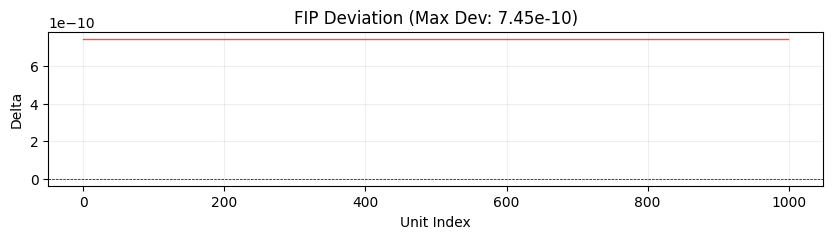

In [ ]:
gbfs.best_design.moran
sample = gbfs.best_design.sample(1)

print(len(sample[0]))
check_inclusions(gbfs.best_design)

In [ ]:
current_file = save_design(gbfs.best_design)

✅ Design saved: best_designs\INITIAL_pop_C1Z1_pop_df_AggregatedPop1000_0515_0044.pkl


In [ ]:
# Run GRIZZLY
gbfs.run(
    max_iterations=1000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=2000,     # maximum number of candidate designs stored in the priority queue (search frontier
    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)
    num_new_order_nodes=100,     # number of neighbors generated by modifying the ordering of samples                           # (creates 20 candidate designs by changing sample order)
    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves                             # (0 means no swapping of units between samples)
    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters                     # (clusters are groups of zones processed together
    num_zones_range=(1,1),                # within a cluster, modify only 1 zone at a time
    num_changes_range=(1,1),              # each generated neighbor performs one order modification                             # (e.g., one swap/reposition in the sequence)
    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)
    pull_strategy='random',   # rule for selecting samples during exchange operations                          # (not used here since exchange neighbors are disabled)
    exchange_coef=.33,          # intensity of unit swapping during exchanges                         # (irrelevant here because num_new_exchange_nodes = 0)
    num_explore=1,               # number of designs expanded per iteration                       # (1 means purely greedy: always expand the current best design)
    window= 20, #lambda iter: random.randint(1, 5)
    n_jobs = 4,
    backtrack_depth=1, 
    stagnation_limit=5000)
gbfs.initial_designs =  [gbfs.best_design]
check_inclusions(gbfs.best_design, plot=False)
# After your 100 iterations are done
# current_file = save_gbfs_state(gbfs)

Starting fresh: Initializing Open Set.
--- Parallel GBFS: Batch Size=1, Workers=4 ---
    GAP USED: [10]
ITR/SuccR    0/1.000 | BST 1277.79 - -0.17653 [ORD] | NEW -2.088047 [ORD] |  1C x 50Z | SIZ  60 | ENT 4.0507
    GAP USED: [1]
ITR/SuccR    0/2.000 | BST 1250.83 - -0.17612 [ORD] | NEW -2.090473 [ORD] |  1C x 50Z | SIZ  60 | ENT 4.0507
    GAP USED: [16]
ITR/SuccR    0/3.000 | BST 1251.20 - -0.17616 [ORD] | NEW -2.090873 [ORD] |  1C x 50Z | SIZ  60 | ENT 4.0507
    GAP USED: [6]
ITR/SuccR    0/4.000 | BST 1333.32 - -0.17828 [ORD] | NEW -2.095872 [ORD] |  1C x 50Z | SIZ  60 | ENT 4.0507
    GAP USED: [4]
ITR/SuccR    0/5.000 | BST 1224.29 - -0.17689 [ORD] | NEW -2.109207 [ORD] |  1C x 50Z | SIZ  60 | ENT 4.0507
    GAP USED: [6]
ITR/SuccR    1/3.000 | BST 1231.72 - -0.17727 [ORD] | NEW -2.112240 [ORD] |  1C x 50Z | SIZ  60 | ENT 4.0507
    GAP USED: [7]
ITR/SuccR    1/3.500 | BST 1210.14 - -0.17767 [ORD] | NEW -2.124371 [ORD] |  1C x 50Z | SIZ  60 | ENT 4.0507
    GAP USED: [10]
ITR/

In [ ]:
# Save a GRIZZLY
current_file = save_gbfs_state(gbfs)

In [ ]:
best_design = gbfs.best_design
best_design.nht_variance

66.38647984723404

In [ ]:
# ============================================================
# EXACT NHT VARIANCE FROM ENUMERATED SAMPLE SPACE
# ============================================================

best_design = gbfs.best_design

# ------------------------------------------------------------
# ALL SAMPLES AND THEIR PROBABILITIES
# ------------------------------------------------------------

samples, probs = best_design.all_samples_and_probs

# ------------------------------------------------------------
# STUDY VARIABLE
# ------------------------------------------------------------

y = best_design.pop.variable

# inclusion probabilities
pik = best_design.pop.inclusions

# ------------------------------------------------------------
# TRUE TOTAL
# ------------------------------------------------------------

t = np.sum(y)

# ------------------------------------------------------------
# NHT ESTIMATORS
# ------------------------------------------------------------

nht_values = []

for s in samples:

    y_s = y[s]

    pik_s = pik[s]

    t_hat = np.sum(y_s / pik_s)
    print(t_hat)

    nht_values.append(t_hat)

nht_values = np.array(nht_values)

# ------------------------------------------------------------
# EXACT DESIGN VARIANCE
# ------------------------------------------------------------

var_nht = np.sum(

    ((nht_values - t) ** 2)

    * probs
)

print("Exact NHT Variance:")
print(var_nht)

2871.826848317928
2871.826848317928
2879.8945945855094
2871.826848317928
2879.8945945855094
2879.8945945855094
2807.998356698538
2807.998356698538
2965.5705605720163
2807.998356698538
2965.5705605720163
2965.5705605720163
2884.7955144107445
2884.7955144107445
2891.6948871799846
2884.7955144107445
2891.6948871799846
2891.6948871799846
2838.023298226154
2838.023298226154
2902.5045948685292
2838.023298226154
2902.5045948685292
2902.5045948685292
2919.276011864859
2919.276011864859
2925.3407351966616
2919.276011864859
2925.3407351966616
2925.3407351966616
2884.3944615346663
2884.3944615346663
2908.6957140018876
2884.3944615346663
2908.6957140018876
2908.6957140018876
2860.0908271794697
2860.0908271794697
2932.906477274337
2860.0908271794697
2932.906477274337
2932.906477274337
2895.5656522339027
2895.5656522339027
2852.2346890088697
2895.5656522339027
2852.2346890088697
2852.2346890088697
2911.108755044458
2911.108755044458
2835.391120490378
2911.108755044458
2835.391120490378
2835.39112049

### Global Searching Flatten GRIZZLY!

In [ ]:
# 1. Flatten the entire frontier
gbfs_global = release_full_grizzly(gbfs)

# 2. Grab the order from the NEW, flattened design
test_order = gbfs_global.best_design.order.copy()

--- Global Release Initiated ---
Processing 9880 candidates from the frontier...


✅ Success! New engine populated with 9881 global candidates.
Current Best Score: -0.430736


In [ ]:
test_order.change(
    num_clusters=1, 
    num_zones=1, 
    num_changes=1, 
    num_zone_changes=0, 
    window=120, 
    coords=pop.coords, 
    debugger_func=audit_intelligent_swap
)

TypeError: audit_intelligent_swap() got an unexpected keyword argument 'order'

In [ ]:
gbfs_global.run(
    max_iterations=2000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=5000,     # maximum number of candidate designs stored in the priority queue (search frontier)
    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)
    num_new_order_nodes=500,     # number of neighbors generated by modifying the ordering of samples
    num_new_exchange_nodes=0,   # number of neighbors generated using exchange moves
    num_clusters_range=(1,1),             # order changes are applied within up to 2 clusters
    num_zones_range=(1, 1),                # within a cluster, modify only 1 zone at a time
    num_changes_range=(1, 1),              # each generated neighbor performs one order modification
    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)
    pull_strategy='defult',   # rule for selecting samples during exchange operations
    exchange_coef=.005,          # intensity of unit swapping during exchanges
    num_explore=1,               # number of designs expanded per iteration
    window=100,
    n_jobs = -1,
    backtrack_depth=100, 
    stagnation_limit=5000,
    output_details=False,
)

In [ ]:
current_file = save_gbfs_state(gbfs_global)

C:\Users\Apc\AppData\Local\Temp\ipykernel_19020\1502334494.py:26: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  pickle.dump(engine, f)


✅ Full search state saved: best_designs\GRIZZLY_pop_C1Z1_score-0.4259_pop_df_AggregatedPop1000_0502_2343.pkl
Candidates waiting in Open Set: 7449
